## 1. Phát biểu mục tiêu / giả thuyết

**Vấn đề:** Nhận diện các ký tự chữ và số đã được tách từ ảnh biển số xe thực tế. Mỗi ảnh ký tự được chuẩn hóa và chuyển thành vector đặc trưng để phân loại bằng KNN.

**Giả thuyết:** Giá trị `K` ảnh hưởng trực tiếp đến khả năng nhận diện. `K` quá nhỏ có thể nhạy với nhiễu, trong khi `K` quá lớn có thể làm các lớp ký tự gần giống nhau bị trộn lẫn. Nhóm dự đoán một giá trị `K` nhỏ đến trung bình, chẳng hạn `K = 3` hoặc `K = 5`, sẽ cho Macro F1-score tốt hơn `K = 1` và các giá trị lớn hơn.

**Tiêu chí thành công:** Giả thuyết được xem là phù hợp nếu một trong các giá trị `K = 3` hoặc `K = 5` đạt Accuracy và Macro F1-score cao nhất hoặc gần cao nhất trên tập test, đồng thời Confusion Matrix cho thấy số lỗi nhầm giữa các lớp giảm.

In [1]:
import argparse
import csv
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from IPython.display import display, Markdown

In [2]:
CHAR_SIZE = (20, 30)  # width, height
DEFAULT_CHAR_DIR = Path("data/char_images")
DEFAULT_MODEL_DIR = Path("model_data")
LABELS_CSV = "labels.csv"
CLASSIFICATIONS_TXT = "classifications.txt"
FLATTENED_IMAGES_TXT = "flattened_images.txt"
KNN_MODEL = "knn_model.yml"
EVALUATION_REPORT = "evaluation_report.txt"
CONFUSION_MATRIX = "confusion_matrix.csv"

In [3]:
# Thư viện dùng cho phần hiển thị và khảo sát tham số
from IPython.display import display, Markdown


In [4]:
def iter_char_images(char_dir):
    return sorted(
        p for p in Path(char_dir).glob("*/*.png")
        if p.is_file() and p.name.startswith("char_")
    )

In [5]:
def preprocess_char(image_path):
    import cv2
    import numpy as np

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Khong doc duoc anh: {image_path}")

    img = cv2.resize(img, CHAR_SIZE)
    img = cv2.GaussianBlur(img, (3, 3), 0)

    _, binary = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    # KNN chi can vector 600 pixel: 20 x 30.
    return binary.reshape(1, -1).astype(np.float32)

In [6]:
def init_labels(char_dir, model_dir):
    model_dir = Path(model_dir)
    model_dir.mkdir(parents=True, exist_ok=True)
    labels_path = model_dir / LABELS_CSV

    existing = {}
    if labels_path.exists():
        with labels_path.open("r", newline="", encoding="utf-8") as f:
            for row in csv.DictReader(f):
                existing[row["image_path"]] = row.get("label", "")

    rows = []
    for image_path in iter_char_images(char_dir):
        key = image_path.as_posix()
        rows.append({"image_path": key, "label": existing.get(key, "")})

    with labels_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["image_path", "label"])
        writer.writeheader()
        writer.writerows(rows)

    print(f"Da tao/cap nhat {labels_path} voi {len(rows)} anh ky tu.")
    print("Hay dien cot label bang ky tu that: 0-9, A-Z.")

In [7]:
def load_labeled_samples(model_dir):
    import numpy as np

    labels_path = Path(model_dir) / LABELS_CSV
    if not labels_path.exists():
        raise FileNotFoundError(
            f"Chua co {labels_path}. Chay: python group4_knn.py init-labels"
        )

    samples = []
    labels = []
    paths = []

    with labels_path.open("r", newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            label = row.get("label", "").strip().upper()
            image_path = Path(row["image_path"])

            if not label:
                continue

            if len(label) != 1:
                raise ValueError(f"Nhan phai la 1 ky tu tai {image_path}: {label}")

            samples.append(preprocess_char(image_path))
            labels.append(ord(label))
            paths.append(image_path)

    if not samples:
        raise ValueError("Chua co anh nao duoc gan nhan trong labels.csv.")

    flattened = np.vstack(samples).astype(np.float32)
    classifications = np.array(labels, dtype=np.float32).reshape(-1, 1)
    return flattened, classifications, paths

In [8]:
def stratified_split(y, test_size=0.25, seed=42):
    import numpy as np

    rng = np.random.default_rng(seed)
    groups = defaultdict(list)

    for idx, label in enumerate(y.ravel().astype(int)):
        groups[label].append(idx)

    train_idx = []
    test_idx = []

    for _, indices in groups.items():
        indices = np.array(indices)
        rng.shuffle(indices)

        if len(indices) == 1:
            train_idx.extend(indices.tolist())
            continue

        n_test = max(1, int(round(len(indices) * test_size)))
        n_test = min(n_test, len(indices) - 1)
        test_idx.extend(indices[:n_test].tolist())
        train_idx.extend(indices[n_test:].tolist())

    return np.array(train_idx), np.array(test_idx)

In [9]:
def train_knn(flattened, classifications, k):
    import cv2

    knn = cv2.ml.KNearest_create()
    knn.setDefaultK(k)
    knn.train(flattened, cv2.ml.ROW_SAMPLE, classifications)
    return knn

In [10]:
def evaluate(knn, x_test, y_test, k):
    import numpy as np

    if len(x_test) == 0:
        return None, []

    _, results, _, _ = knn.findNearest(x_test, k=k)
    y_true = y_test.ravel().astype(int)
    y_pred = results.ravel().astype(int)
    accuracy = float(np.mean(y_true == y_pred))
    rows = [(chr(t), chr(p)) for t, p in zip(y_true, y_pred)]
    return accuracy, rows

In [11]:
def write_evaluation(model_dir, accuracy, confusion_rows, label_counts, k):
    model_dir = Path(model_dir)
    report_path = model_dir / EVALUATION_REPORT
    matrix_path = model_dir / CONFUSION_MATRIX

    with report_path.open("w", encoding="utf-8") as f:
        f.write("Bao cao danh gia KNN - Nhom 4\n")
        f.write(f"K = {k}\n")
        f.write(f"So mau da gan nhan = {sum(label_counts.values())}\n")
        f.write("Phan bo nhan:\n")
        for label, count in sorted(label_counts.items()):
            f.write(f"- {label}: {count}\n")

        if accuracy is None:
            f.write("Chua du mau test de tinh accuracy.\n")
        else:
            f.write(f"Accuracy = {accuracy:.4f}\n")
            errors = [(t, p) for t, p in confusion_rows if t != p]
            f.write(f"So mau sai = {len(errors)}\n")
            if errors:
                f.write("Cac loi nhan dien:\n")
                for true_label, pred_label in errors:
                    f.write(f"- {true_label} -> {pred_label}\n")

    labels = sorted({x for row in confusion_rows for x in row})
    counts = Counter(confusion_rows)

    with matrix_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["true\\pred", *labels])
        for true_label in labels:
            writer.writerow(
                [true_label, *[counts[(true_label, pred_label)] for pred_label in labels]]
            )

    print(f"Da ghi {report_path}")
    print(f"Da ghi {matrix_path}")

In [12]:
def train_command(args):
    import numpy as np

    model_dir = Path(args.model_dir)
    model_dir.mkdir(parents=True, exist_ok=True)

    flattened, classifications, _ = load_labeled_samples(model_dir)
    labels_as_chars = [chr(x) for x in classifications.ravel().astype(int)]
    label_counts = Counter(labels_as_chars)

    if len(label_counts) < 2:
        raise ValueError("Can it nhat 2 lop ky tu khac nhau de danh gia KNN.")

    np.savetxt(model_dir / FLATTENED_IMAGES_TXT, flattened)
    np.savetxt(model_dir / CLASSIFICATIONS_TXT, classifications)

    train_idx, test_idx = stratified_split(
        classifications,
        test_size=args.test_size,
        seed=args.seed,
    )

    knn = train_knn(flattened[train_idx], classifications[train_idx], args.k)
    accuracy, confusion_rows = evaluate(
        knn,
        flattened[test_idx],
        classifications[test_idx],
        args.k,
    )

    full_knn = train_knn(flattened, classifications, args.k)
    full_knn.save(str(model_dir / KNN_MODEL))
    write_evaluation(model_dir, accuracy, confusion_rows, label_counts, args.k)

    print(f"Da luu {model_dir / CLASSIFICATIONS_TXT}")
    print(f"Da luu {model_dir / FLATTENED_IMAGES_TXT}")
    print(f"Da luu {model_dir / KNN_MODEL}")
    if accuracy is not None:
        print(f"Accuracy: {accuracy:.4f}")

In [13]:
def predict_folder(args):
    import cv2

    model_path = Path(args.model_dir) / KNN_MODEL
    if not model_path.exists():
        raise FileNotFoundError(f"Chua co model: {model_path}")

    knn = cv2.ml.KNearest_load(str(model_path))
    chars = []

    for image_path in sorted(Path(args.folder).glob("char_*.png")):
        sample = preprocess_char(image_path)
        _, result, _, _ = knn.findNearest(sample, k=args.k)
        chars.append(chr(int(result[0][0])))

    print("".join(chars))

## 2. Minh họa các bước tiền xử lý

Các bước chính:

1. Đọc ảnh xám.
2. Resize về `20 x 30` pixel.
3. Gaussian Blur để giảm nhiễu.
4. Otsu Threshold để tạo ảnh nhị phân.
5. Trải phẳng thành vector `600` đặc trưng.

In [14]:
def show_preprocessing_steps(image_path):
    image_path = Path(image_path)
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f'Không đọc được ảnh: {image_path}')

    resized = cv2.resize(gray, (20, 30))
    blurred = cv2.GaussianBlur(resized, (3, 3), 0)
    _, binary = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    images = [gray, resized, blurred, binary]
    titles = ['Ảnh gốc', 'Resize 20x30', 'Gaussian Blur', 'Otsu Threshold']

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print('Kích thước ảnh sau resize:', resized.shape)
    print('Số chiều vector đặc trưng:', binary.reshape(1, -1).shape[1])


In [15]:
# Tự động lấy một ảnh đã gán nhãn để minh họa
labels_file = Path(DEFAULT_MODEL_DIR) / LABELS_CSV
labels_df = pd.read_csv(labels_file)

if labels_df.empty:
    raise ValueError('labels.csv đang rỗng.')

sample_path = Path(str(labels_df.iloc[0]['image_path']))
if not sample_path.exists():
    candidate = labels_file.parent / sample_path
    if candidate.exists():
        sample_path = candidate

show_preprocessing_steps(sample_path)


NameError: name 'cv2' is not defined

### Nhận xét tiền xử lý

- Resize giúp mọi ảnh có cùng số chiều đặc trưng.
- Gaussian Blur làm giảm nhiễu nhỏ trước khi nhị phân hóa.
- Otsu tự động chọn ngưỡng dựa trên phân bố mức xám, giúp tách ký tự khỏi nền.
- Sau tiền xử lý, mỗi ảnh được biểu diễn bởi vector 600 chiều để KNN so sánh khoảng cách.

## 3. Huấn luyện và đánh giá mô hình KNN

Phần này hiển thị đầy đủ thông số dữ liệu, Accuracy, Precision, Recall, F1-score, phân bố nhãn, Confusion Matrix và các mẫu dự đoán sai.

In [ ]:
def evaluate_knn(model_dir=DEFAULT_MODEL_DIR, k=3, test_size=0.25, seed=42):
    model_dir = Path(model_dir)
    X, y, paths = load_labeled_samples(model_dir)
    y = y.ravel().astype(int)

    if not 0 < test_size < 1:
        raise ValueError('test_size phải nằm trong khoảng (0, 1).')

    train_idx, test_idx = stratified_split(y.reshape(-1, 1), test_size, seed)
    if not len(test_idx):
        raise ValueError('Không có mẫu test.')
    if k < 1 or k > len(train_idx):
        raise ValueError(f'k phải nằm trong khoảng 1 đến {len(train_idx)}.')

    knn = train_knn(X[train_idx], y[train_idx].reshape(-1, 1), k)
    _, result, _, distances = knn.findNearest(X[test_idx], k=k)

    y_true = y[test_idx]
    y_pred = result.ravel().astype(int)
    labels = sorted(set(y_true) | set(y_pred))
    names = [chr(v) for v in labels]
    accuracy = float(np.mean(y_true == y_pred))

    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    pos = {label: i for i, label in enumerate(labels)}
    rows = []

    for true_label, pred_label in zip(y_true, y_pred):
        matrix[pos[true_label], pos[pred_label]] += 1

    for label in labels:
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        support = np.sum(y_true == label)
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        rows.append([chr(label), precision, recall, f1, support])

    report = pd.DataFrame(
        rows,
        columns=['Nhãn', 'Precision', 'Recall', 'F1-score', 'Support']
    )

    distribution = pd.DataFrame(
        sorted(Counter(chr(v) for v in y).items()),
        columns=['Nhãn', 'Số lượng']
    )

    summary = pd.DataFrame({
        'Thông số': [
            'Tổng số mẫu', 'Số lớp', 'Số mẫu train', 'Số mẫu test',
            'K', 'Test size', 'Seed', 'Số chiều đặc trưng',
            'Dự đoán đúng', 'Dự đoán sai', 'Accuracy',
            'Macro Precision', 'Macro Recall', 'Macro F1-score'
        ],
        'Giá trị': [
            len(X), len(set(y)), len(train_idx), len(test_idx),
            k, test_size, seed, X.shape[1],
            int(np.sum(y_true == y_pred)), int(np.sum(y_true != y_pred)),
            f'{accuracy:.4f} ({accuracy:.2%})',
            f'{report["Precision"].mean():.4f}',
            f'{report["Recall"].mean():.4f}',
            f'{report["F1-score"].mean():.4f}'
        ]
    })

    details = pd.DataFrame({
        'Ảnh': [str(paths[i]) for i in test_idx],
        'Nhãn thật': [chr(v) for v in y_true],
        'Dự đoán': [chr(v) for v in y_pred],
        'Kết quả': ['Đúng' if t == p else 'Sai' for t, p in zip(y_true, y_pred)],
        'Khoảng cách TB': distances.mean(axis=1)
    })

    display(Markdown('## Thông số tổng quát'))
    display(summary)

    display(Markdown('## Phân bố dữ liệu'))
    display(distribution)
    distribution.plot(kind='bar', x='Nhãn', y='Số lượng', legend=False, figsize=(9, 4))
    plt.title('Phân bố số mẫu theo nhãn')
    plt.ylabel('Số mẫu')
    plt.tight_layout()
    plt.show()

    display(Markdown('## Precision, Recall và F1-score'))
    display(report.style.format({
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-score': '{:.4f}'
    }))

    display(Markdown('## Confusion matrix'))
    display(pd.DataFrame(matrix, index=names, columns=names))
    plt.figure(figsize=(7, 6))
    plt.imshow(matrix)
    plt.title('Confusion Matrix - KNN')
    plt.xlabel('Nhãn dự đoán')
    plt.ylabel('Nhãn thật')
    plt.xticks(range(len(names)), names)
    plt.yticks(range(len(names)), names)
    plt.colorbar()
    for i in range(len(names)):
        for j in range(len(names)):
            plt.text(j, i, matrix[i, j], ha='center', va='center')
    plt.tight_layout()
    plt.show()

    display(Markdown('## Các mẫu dự đoán sai'))
    display(details[details['Kết quả'] == 'Sai'])

    full_knn = train_knn(X, y.reshape(-1, 1), k)
    full_knn.save(str(model_dir / KNN_MODEL))

    return {
        'summary': summary,
        'distribution': distribution,
        'report': report,
        'confusion_matrix': matrix,
        'details': details,
        'accuracy': accuracy
    }


## Thông số tổng quát

,Thông số,Giá trị
0,Tổng số mẫu,115
1,Số lớp,18
2,Số mẫu train,86
3,Số mẫu test,29
4,K,3
5,Test size,0.25
6,Seed,42
7,Số chiều đặc trưng,600
8,Dự đoán đúng,21
9,Dự đoán sai,8


## Phân bố dữ liệu

,Nhãn,Số lượng
0,0,17
1,1,16
2,2,12
3,3,7
4,4,5
5,5,16
6,6,8
7,7,4
8,8,4
9,9,11


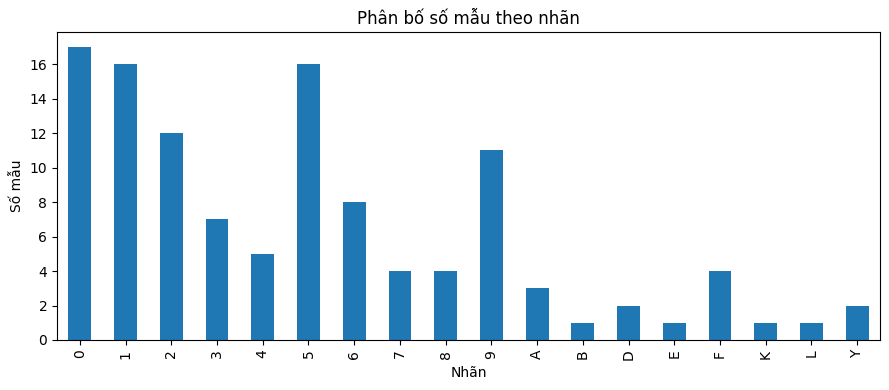

## Precision, Recall và F1-score

,Nhãn,Precision,Recall,F1-score,Support
0,0,0.3333,0.7500,0.4615,4
1,1,0.6667,1.0000,0.8000,4
2,2,1.0000,1.0000,1.0000,3
3,3,1.0000,0.5000,0.6667,2
4,4,1.0000,1.0000,1.0000,1
5,5,1.0000,0.7500,0.8571,4
6,6,1.0000,0.5000,0.6667,2
7,7,0.0000,0.0000,0.0000,1
8,8,0.0000,0.0000,0.0000,1
9,9,1.0000,1.0000,1.0000,3


## Confusion matrix

,0,1,2,3,4,5,6,7,8,9,A,D,F,Y
0,3,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,4,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,3,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,3,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,1,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,3,0,0,0,0


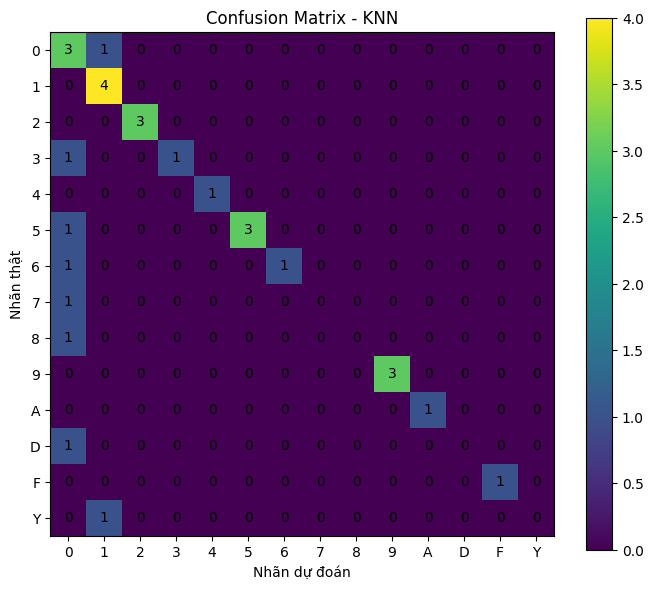

## Các mẫu dự đoán sai

,Ảnh,Nhãn thật,Dự đoán,Kết quả,Khoảng cách TB
1,data\char_images\greenpack_1582\char_01.png,5,0,Sai,4768500.0
11,data\char_images\Dieu_0108\char_04.png,7,0,Sai,8084774.5
13,data\char_images\Tgmt_0305\char_08.png,0,1,Sai,6177374.5
19,data\char_images\Tgmt_0066\char_02.png,D,0,Sai,9060149.0
20,data\char_images\Tgmt_0066\char_05.png,6,0,Sai,6090674.5
22,data\char_images\Tgmt_0066\char_06.png,8,0,Sai,8604975.0
23,data\char_images\greenpack_1582\char_08.png,3,0,Sai,3229575.0
26,data\char_images\carlong_0239\char_02.png,Y,1,Sai,4681800.0


In [ ]:
results = evaluate_knn(
    model_dir=DEFAULT_MODEL_DIR,
    k=3,
    test_size=0.25,
    seed=42
)


## 4. Hàm đánh giá một giá trị K

In [ ]:
def evaluate_one_k(X, y, train_idx, test_idx, k):
    knn = train_knn(X[train_idx], y[train_idx].reshape(-1, 1), k)
    _, result, _, _ = knn.findNearest(X[test_idx], k=k)

    y_true = y[test_idx]
    y_pred = result.ravel().astype(int)
    labels = sorted(set(y_true) | set(y_pred))

    precision_list = []
    recall_list = []
    f1_list = []

    for label in labels:
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return {
        'K': k,
        'Accuracy': np.mean(y_true == y_pred),
        'Macro Precision': np.mean(precision_list),
        'Macro Recall': np.mean(recall_list),
        'Macro F1': np.mean(f1_list),
        'Đúng': int(np.sum(y_true == y_pred)),
        'Sai': int(np.sum(y_true != y_pred)),
    }


## 5. Khảo sát tham số K

```text
K = 1, 3, 5, 7
```

In [ ]:
X, classifications, paths = load_labeled_samples(Path(DEFAULT_MODEL_DIR))
y = classifications.ravel().astype(int)

test_size = 0.25
seed = 42
train_idx, test_idx = stratified_split(classifications, test_size, seed)

k_values = [1, 3, 5, 7]
k_values = [k for k in k_values if k <= len(train_idx)]

sweep_results = pd.DataFrame([
    evaluate_one_k(X, y, train_idx, test_idx, k)
    for k in k_values
])

display(Markdown('### Bảng kết quả khảo sát K'))
display(sweep_results.style.format({
    'Accuracy': '{:.4f}',
    'Macro Precision': '{:.4f}',
    'Macro Recall': '{:.4f}',
    'Macro F1': '{:.4f}',
}))


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(sweep_results['K'], sweep_results['Accuracy'], marker='o', label='Accuracy')
plt.plot(sweep_results['K'], sweep_results['Macro F1'], marker='o', label='Macro F1')
plt.xlabel('Giá trị K')
plt.ylabel('Điểm số')
plt.title('Ảnh hưởng của K đến kết quả KNN')
plt.xticks(sweep_results['K'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Tự động chọn K tốt nhất

In [ ]:
best_row = sweep_results.sort_values(
    ['Macro F1', 'Accuracy'], ascending=False
).iloc[0]

best_k = int(best_row['K'])

display(Markdown(
    f'**K tốt nhất theo Macro F1:** `{best_k}`  \n'
    f'**Accuracy:** `{best_row["Accuracy"]:.4f}`  \n'
    f'**Macro Precision:** `{best_row["Macro Precision"]:.4f}`  \n'
    f'**Macro Recall:** `{best_row["Macro Recall"]:.4f}`  \n'
    f'**Macro F1:** `{best_row["Macro F1"]:.4f}`'
))


## 7. Mẫu nhận xét kết quả

Nhóm đã khảo sát các giá trị K gồm 1, 3, 5 và 7 trên cùng một cách chia dữ liệu với test size bằng 0.25 và seed bằng 42. Kết quả cho thấy K = **...** đạt Macro F1-score cao nhất là **...**, đồng thời Accuracy đạt **...**. Khi K quá nhỏ, mô hình có xu hướng nhạy với nhiễu và các mẫu bất thường. Khi K tăng quá lớn, quyết định phân loại chịu ảnh hưởng từ nhiều mẫu thuộc các lớp khác nhau, đặc biệt với các ký tự có hình dạng gần giống nhau. Vì vậy nhóm chọn K = **...** cho mô hình cuối cùng.

## 8. Đối chiếu với giả thuyết

Sau khi có kết quả, chọn một trong ba kết luận:

- **Giả thuyết đúng:** nếu K = 3 hoặc K = 5 đạt kết quả tốt nhất.
- **Giả thuyết đúng một phần:** nếu chênh lệch giữa các K rất nhỏ hoặc K tốt nhất nằm gần khoảng dự đoán.
- **Giả thuyết sai:** nếu K = 1 hoặc một giá trị lớn hơn cho kết quả vượt trội.

Điều quan trọng là giải thích kết quả dựa trên dữ liệu, không cần cố chứng minh giả thuyết ban đầu luôn đúng.